# Final model evaluation

## tl;dr

The locked 300-tree research model was fitted on 1990–2010 and evaluated once on the previously sealed 2011–2013 test period. It achieved **MAE 11,065.87 hg/ha**, **RMSE 21,938.75 hg/ha**, and **R² 0.9382**, with no negative predictions. The browser-deployable depth-capped forest achieved **MAE 11,815.30 hg/ha** and **R² 0.9343**. The live application therefore accepts a modest accuracy trade-off for a portable artifact while preserving the full research result in the model card.

## Context & Methods

### Key assumptions

- Model and hyperparameter selection ended before opening the test period.
- Training and validation were combined only after selection.
- The test period is used for final reporting, not further tuning.
- Reported relationships are predictive, not causal.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from crop_yield.production import evaluate_locked_model

data = pd.read_csv(ROOT / 'data/processed/crop_yield_modeling.csv')
data.shape

(13130, 7)

## Results

In [2]:
_, research_result, research_predictions = evaluate_locked_model(data)
_, deployment_result, deployment_predictions = evaluate_locked_model(
    data, deployment_optimized=True
)

pd.DataFrame([research_result.__dict__, deployment_result.__dict__])

                    model_name training_period test_period  train_rows  test_rows  mae_hg_per_ha  rmse_hg_per_ha        r2  negative_predictions
0  random_forest_300_unbounded       1990-2010   2011-2013       11360       1770   11065.874252    21938.749584  0.938161                     0
1   random_forest_100_depth_18       1990-2010   2011-2013       11360       1770   11815.303452    22615.225643  0.934289                     0

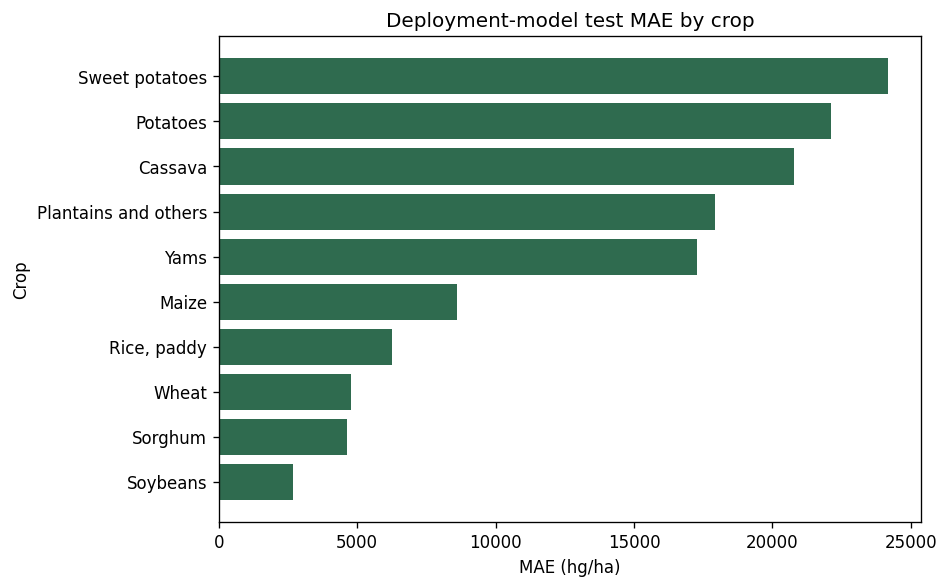

In [3]:
crop_error = (
    deployment_predictions.groupby('item', as_index=False)
    ['absolute_error_hg_per_ha'].mean()
    .sort_values('absolute_error_hg_per_ha')
)
ax = crop_error.plot.barh(
    x='item', y='absolute_error_hg_per_ha', legend=False,
    color='#2f6b4f', figsize=(8, 5)
)
ax.set(title='Deployment-model test MAE by crop', xlabel='MAE (hg/ha)', ylabel='Crop')
plt.tight_layout()

## Takeaways

- The final test result confirms strong interpolation across known country–crop combinations.
- The deployed model keeps R² above 0.93 while remaining small enough for an interactive browser application.
- Cassava, potatoes, sweet potatoes, plantains, and yams require the most caution.
- This is a historical conditional estimator. The random forest does not learn a reliable long-horizon year trend, so the interface restricts years to the observed 1990–2013 range.